# Analysis of the Relationship Between Product Categories and Sales Effectiveness (Inner)

## Member: Phuong

### Bàn luận:
Dựa trên phần EDA, ta có thể thấy có 5 root mỗi root chứa nhiều middle, mỗi middle chứa nhiều leaf
Vì vậy có rất nhiều thứ cần phải phân tích trong một danh mục.
Để đảm bảo insight được khách quan và thực sự cung cấp thông tin hữu ích cho người đọc. Em sẽ tiếp cận bằng một mục tiêu phân tích bao quát nhất

### Analysis Objectives:
1. **Question 1**: Với từng root danh mục, danh mục con trực tiếp nào đang phát triển mạnh nhất (doanh thu, số danh mục con, tổng sản phẩm)?
2. **Question 2**: Khám phá chuyên sâu những danh mục phát triển mạnh nhất đó xem yếu tố nào chính là yếu tố ảnh hưởng lớn nhất (Dùng linear để predict r xem cái nào có trọng số cao nhất)?

vde: 
Câu 1: chốt doanh thu là gì
Câu 2: 
- Phải chọn được target rõ ràng (chứ “r” hiện tại hơi mơ hồ – bạn nên ghi lại: “Dùng linear để predict doanh thu / số đơn / rating…”).
- Đủ số lượng quan sát trong mỗi danh mục mạnh (nếu làm model riêng từng danh mục) hoặc làm chung rồi thêm dummy category.
- Chấp nhận rằng linear chỉ cho bạn insight tuyến tính, không phải là “chân lý” nhân quả.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

# Display configuration
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

# Create output directory if not exists
output_dir = '../output'
os.makedirs(output_dir, exist_ok=True)

## 1. Load Common Data

In [2]:
# Load 4 common data tables following team standards
df_store = pd.read_csv('../data/stores.csv')
df_category = pd.read_csv('../data/categories.csv')
df_product = pd.read_csv('../data/products.csv')
df_review = pd.read_csv('../data/reviews.csv')

print("Data Size:")
print(f"Stores: {df_store.shape}")
print(f"Categories: {df_category.shape}")
print(f"Products: {df_product.shape}")
print(f"Reviews: {df_review.shape}")

Data Size:
Stores: (1446, 5)
Categories: (497, 4)
Products: (55883, 14)
Reviews: (158126, 8)


## 2. Category Exploration
- Khám phá các root category (trỏng có bao nhiêu nhánh)
- EDA cơ bản về dữ liệu từng category (doanh thu tổng, chart danh thu cho từng category)
- ...

## 3. Question 1: 

Chốt: doanh thu = discounted_price (nếu có) * sold (nếu không có discounted_price thì dùng price)
Note: nói trong câu 1 là mình chấp nhận tính tương đối của doanh thu

In [10]:
import pandas as pd
from IPython.display import display

# ==========================================
# PHẦN 1: CHUẨN HÓA VÀ XÂY DỰNG CÂY DANH MỤC
# ==========================================

df_category = df_category.copy()
df_category['category_id'] = df_category['category_id'].astype(str)
df_category['category_name_clean'] = df_category['category_name'].astype(str).str.strip()
df_category['parent_category_clean'] = df_category['parent_category'].fillna('').astype(str).str.strip()

# 1. Xác định Root categories (cấp 1)
root_categories = df_category.loc[
    df_category['parent_category_clean'] == '', 
    ['category_id', 'category_name_clean']
].rename(columns={'category_name_clean': 'root_name'})
root_names_set = set(root_categories['root_name'])

# 2. Xây dựng hàm dò tìm tổ tiên cấp 2 (L2 Ancestor)
parent_dict = dict(zip(df_category['category_name_clean'], df_category['parent_category_clean']))

def get_l2_ancestor(cat_name):
    """Hàm dò ngược từ 1 danh mục bất kỳ lên danh mục cấp 2 (con trực tiếp của Root)"""
    current = cat_name
    visited = set()
    while current and current in parent_dict:
        parent = parent_dict[current]
        if parent in root_names_set:
            return current  # Đã tìm thấy danh mục cấp 2
        if current in visited:
            break  # Chống lặp vô hạn nếu data bị lỗi vòng lặp
        visited.add(current)
        current = parent
    return None

# Map L2_ancestor cho TOÀN BỘ danh mục
df_category['L2_ancestor'] = df_category['category_name_clean'].apply(get_l2_ancestor)

# 3. Đếm số danh mục con trực tiếp cho mục đích hiển thị
child_counts = df_category.groupby('parent_category_clean')['category_id'].count()


# ==========================================
# PHẦN 2: TÍNH DOANH THU & ROLL-UP DỮ LIỆU
# ==========================================

df_product = df_product.copy()
df_product['category_id'] = df_product['category_id'].astype(str)
df_product['price'] = df_product['price'].astype(float)
df_product['sold_count'] = df_product['sold_count'].fillna(0).astype(int)
df_product['revenue'] = df_product['price'] * df_product['sold_count']

# Map sản phẩm với danh mục cấp 2 tương ứng của nó
cat_to_l2_dict = dict(zip(df_category['category_id'], df_category['L2_ancestor']))
df_product['L2_ancestor'] = df_product['category_id'].map(cat_to_l2_dict)

# Gom nhóm theo L2_ancestor THAY VÌ category_id trực tiếp
if 'product_id' in df_product.columns:
    cat_revenue = df_product.groupby('L2_ancestor', as_index=False).agg(
        total_revenue=('revenue', 'sum'),
        product_count=('product_id', 'nunique'),
    )
else:
    cat_revenue = df_product.groupby('L2_ancestor', as_index=False).agg(
        total_revenue=('revenue', 'sum'),
        product_count=('revenue', 'size'),
    )


# ==========================================
# PHẦN 3: LỌC TOP 1 CHO MỖI ROOT
# ==========================================

# Chỉ lấy danh sách các danh mục cấp 2 (con trực tiếp của Root) để làm khung báo cáo
q1_summary = df_category[df_category['parent_category_clean'].isin(root_names_set)].copy()

q1_summary = q1_summary[['category_id', 'category_name_clean', 'parent_category_clean']].rename(
    columns={'parent_category_clean': 'root_name'}
)
q1_summary['direct_child_count'] = q1_summary['category_name_clean'].map(child_counts).fillna(0).astype(int)

# Gộp tổng doanh thu đã cuộn (Roll-up) vào bảng
q1_summary = q1_summary.merge(cat_revenue, left_on='category_name_clean', right_on='L2_ancestor', how='left')
q1_summary['total_revenue'] = q1_summary['total_revenue'].fillna(0)
q1_summary['product_count'] = q1_summary['product_count'].fillna(0).astype(int)
q1_summary = q1_summary.drop(columns=['L2_ancestor'])

# Sắp xếp và lấy Top 1
q1_summary = q1_summary.sort_values(by=['total_revenue', 'product_count'], ascending=[False, False])
top1_per_root = q1_summary.groupby('root_name').head(1).reset_index(drop=True)

# Format Index lại từ 1
top1_per_root.index = top1_per_root.index + 1


# ==========================================
# PHẦN 4: HIỂN THỊ TRỰC QUAN
# ==========================================

def format_to_millions(val):
    if pd.isna(val): return val
    return f"{val / 1_000_000:,.2f} Tr"

fmt_summary = {'total_revenue': format_to_millions}

print('--- 1. Root categories ---')
display(root_categories)

print('\n--- 2. TOP 1 danh mục con trực tiếp xuất sắc nhất của TỪNG Root Category ---')
display(top1_per_root[['root_name', 'category_id', 'category_name_clean', 'direct_child_count', 'product_count', 'total_revenue']].style.format(fmt_summary))

--- 1. Root categories ---


,category_id,root_name
0,1882,Dien gia dung
138,1789,Dien thoai - May tinh bang
144,4221,Dien tu - Dien lanh
198,1846,Laptop - May vi tinh - Linh kien
291,1815,Thiet bi so - Phu kien so



--- 2. TOP 1 danh mục con trực tiếp xuất sắc nhất của TỪNG Root Category ---


,root_name,category_id,category_name_clean,direct_child_count,product_count,total_revenue
1,Dien thoai - May tinh bang,1795,Điện thoại Smartphone,0,117,"368,812.27 Tr"
2,Dien gia dung,1884,Đồ dùng nhà bếp,24,7128,"332,858.66 Tr"
3,Dien tu - Dien lanh,3862,Máy giặt,4,225,"111,206.29 Tr"
4,Laptop - May vi tinh - Linh kien,12884,Thiết Bị Văn Phòng - Thiết Bị Ngoại Vi,13,3460,"91,966.67 Tr"
5,Thiet bi so - Phu kien so,28670,Phụ kiện máy tính và Laptop,10,4968,"48,916.68 Tr"


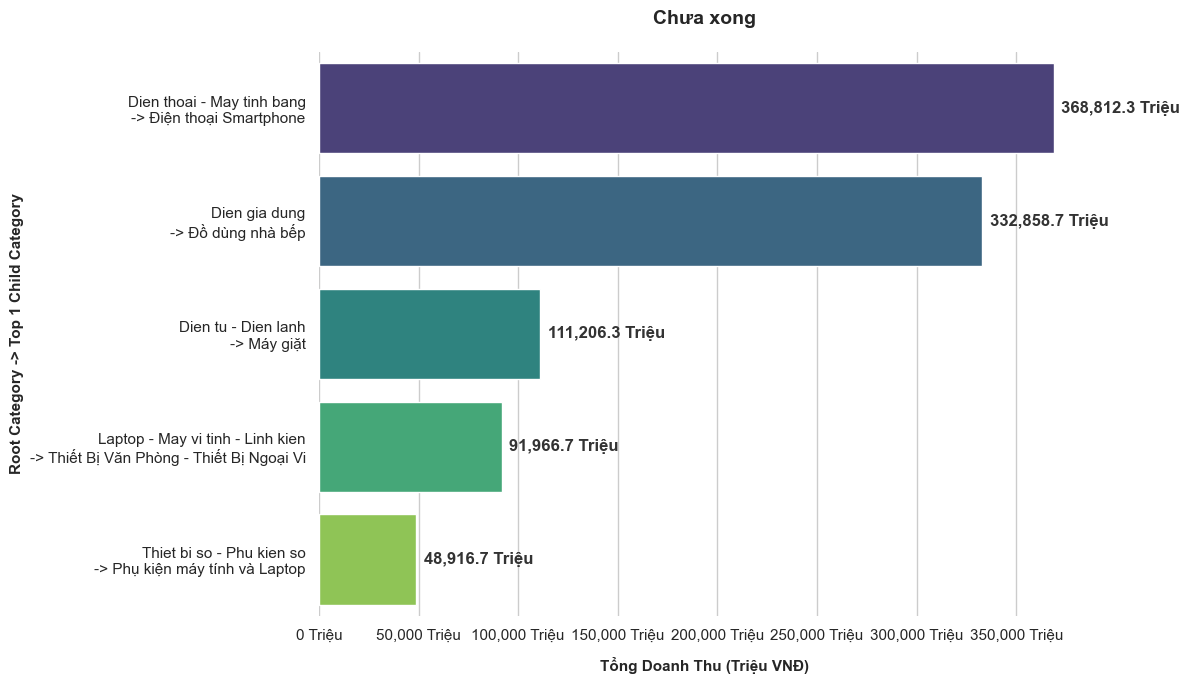

In [17]:
# Visualize 
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# ==========================================
# TRỰC QUAN HÓA DỮ LIỆU (VISUALIZATION)
# ==========================================

# 1. Cài đặt font chữ và style cơ bản để biểu đồ nhìn hiện đại
plt.rcParams['font.family'] = 'sans-serif'
sns.set_theme(style="whitegrid")

# 2. Tạo một cột nhãn mới gộp cả tên Root và Tên Child để dễ đọc trên biểu đồ
# Ví dụ: "Đồ gia dụng \n-> Đồ dùng nhà bếp"
top1_per_root_plot = top1_per_root.copy()
top1_per_root_plot['display_label'] = top1_per_root_plot['root_name'] + '\n-> ' + top1_per_root_plot['category_name_clean']

# Sắp xếp lại dữ liệu theo doanh thu giảm dần để biểu đồ đẹp hơn (như bậc thang)
top1_per_root_plot = top1_per_root_plot.sort_values('total_revenue', ascending=False)

# 3. Khởi tạo Figure
plt.figure(figsize=(12, 7))

# 4. Vẽ biểu đồ cột ngang (Barplot)
ax = sns.barplot(
    data=top1_per_root_plot,
    x='total_revenue',
    y='display_label',
    palette='viridis', # Tone màu từ đậm đến nhạt nhìn rất chuyên nghiệp
    hue='display_label', # Thêm hue để gán màu theo từng dòng, tránh warning của Seaborn mới
    legend=False
)

# 5. Format trục X về đơn vị Triệu (Tr)
def millions_formatter(x, pos):
    return f'{x / 1_000_000:,.0f} Triệu'
ax.xaxis.set_major_formatter(FuncFormatter(millions_formatter))

# 6. Thêm Text hiển thị số tiền chính xác ngay đuôi mỗi cột
max_revenue = top1_per_root_plot['total_revenue'].max()
for i, v in enumerate(top1_per_root_plot['total_revenue']):
    # Vị trí text xê dịch một chút sang phải so với đuôi cột (khoảng 1% của max_revenue)
    ax.text(v + (max_revenue * 0.01), i, 
            f'{v / 1_000_000:,.1f} Triệu', 
            va='center', fontweight='bold', color='#333333')

# 7. Căn chỉnh Tiêu đề và Nhãn trục
plt.title('Chưa xong', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Tổng Doanh Thu (Triệu VNĐ)', fontsize=11, fontweight='bold', labelpad=10)
plt.ylabel('Root Category -> Top 1 Child Category', fontsize=11, fontweight='bold')

# Bỏ đường viền trên và phải cho biểu đồ thoáng hơn
sns.despine(left=True, bottom=True)

# 8. Hiển thị
plt.tight_layout()
plt.show()

### Analysis and Conclusion - Question 1

#### Key Observations:

1. 
2. 
3. 
#### Conclusion:


## 4. Question 2: 

In [ ]:
#set up

In [ ]:
# visualize

### Analysis and Conclusion - Question 2

#### Key Observations:

1. 
2. 
3. 

#### Conclusion:


---
## OVERALL CONCLUSION
